# Laboratorio 13 - Painel de Governanca: Incidentes, Problemas e SLA

**Disciplina:** Gestao de Sistemas de Informacao  
**Empresa ficticia:** TechStore S.A.  
**Roteiro:** Metadados de Governanca e Problemas em ITIL com Python  
**Atividade implementada:** Atividade 3 - Painel de Governanca

Este notebook funciona como relatorio, implementacao e evidencia de execucao da atividade.
Como a Atividade 3 depende de `df_incidentes` e `df_problemas`, a preparacao dos dados da
Atividade 2 foi recriada antes do painel.


## 1. Objetivo

Construir um painel de governanca que consolide, por servico:

- volume total de incidentes;
- quantidade de incidentes de Prioridade Alta;
- existencia de Problema aberto;
- taxa de servicos com Problema aberto em relacao ao total monitorado.

O resultado ajuda a gestao de TI a identificar servicos com recorrencia critica e maior exposicao
a metas de SLA para chamados de prioridade Alta.


## 2. Fundamentacao teorica resumida

| Conceito | Aplicacao no laboratorio |
|---|---|
| Incidente | Interrupcao ou degradacao percebida em um servico de TI. |
| Problema | Registro criado quando incidentes recorrentes indicam necessidade de investigar causa raiz. |
| Prioridade | Combina impacto e urgencia; aqui, chamados de Prioridade Alta sao o foco de risco. |
| Severidade | Mede a gravidade tecnica do incidente, de 1 (critico) a 4 (baixo). |
| SLA | Define metas mensuraveis; incidentes Alta exigem maior controle por terem impacto maior. |

Na logica do ITIL, incidentes sao sintomas operacionais. Problemas representam investigacao
da causa raiz para reduzir repeticao e impacto futuro.


## 3. Preparacao do ambiente

Usamos `pandas` para manipulacao tabular, `random` para gerar uma massa de dados reprodutivel
e `matplotlib` para gerar uma evidencia visual do painel.


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 20)

RANDOM_SEED = 99
N_INCIDENTES = 30
PRIORIDADES = ["Alta", "Media", "Baixa"]
SEVERIDADES = [1, 2, 3, 4]
SERVICOS = [
    "ERP",
    "Portal do Cliente",
    "Sistema de Pagamentos",
    "E-mail Corporativo",
]
LIMITE_PROBLEMA = 3

SAIDAS_DIR = Path("saidas")
SAIDAS_DIR.mkdir(exist_ok=True)


## 4. Base de incidentes usada no painel

A Atividade 3 reaproveita os dados da Atividade 2. Por isso, geramos um log com 30 incidentes,
cada um contendo `ticket_id`, `servico`, `prioridade` e `severidade`.

O uso de `RANDOM_SEED = 99` garante que a execucao gere sempre os mesmos registros, permitindo
conferir o resultado e reproduzir o relatorio.


In [2]:
def gerar_log_incidentes(seed: int = RANDOM_SEED, n_incidentes: int = N_INCIDENTES) -> pd.DataFrame:
    """Gera um log ficticio de incidentes da TechStore S.A."""
    rng = random.Random(seed)
    return pd.DataFrame(
        {
            "ticket_id": range(5001, 5001 + n_incidentes),
            "servico": [rng.choice(SERVICOS) for _ in range(n_incidentes)],
            "prioridade": [rng.choice(PRIORIDADES) for _ in range(n_incidentes)],
            "severidade": [rng.choice(SEVERIDADES) for _ in range(n_incidentes)],
        }
    )


df_incidentes = gerar_log_incidentes()

print("=== LOG DE INCIDENTES POR SERVICO - TECHSTORE S.A. ===")
display(df_incidentes)


=== LOG DE INCIDENTES POR SERVICO - TECHSTORE S.A. ===


,ticket_id,servico,prioridade,severidade
0,5001,E-mail Corporativo,Media,1
1,5002,E-mail Corporativo,Alta,4
2,5003,Portal do Cliente,Media,1
3,5004,Portal do Cliente,Baixa,2
4,5005,Portal do Cliente,Alta,3
5,5006,Portal do Cliente,Media,1
6,5007,Portal do Cliente,Baixa,4
7,5008,ERP,Alta,3
8,5009,Sistema de Pagamentos,Baixa,2
9,5010,E-mail Corporativo,Media,4


## 5. Preparacao dos Registros de Problema

Politica da TechStore S.A.:

> Se um mesmo servico tiver 3 ou mais incidentes de Prioridade Alta no periodo,
> deve ser aberto um Problema para investigacao da causa raiz.

Essa etapa cria `df_problemas`, objeto necessario para a montagem do painel de governanca.


In [3]:
incidentes_alta = df_incidentes[df_incidentes["prioridade"] == "Alta"]

contagem_alta_por_servico = (
    incidentes_alta.groupby("servico")["ticket_id"]
    .count()
    .reindex(SERVICOS, fill_value=0)
    .astype(int)
)


def abrir_problemas(contagem_alta: pd.Series, limite: int = LIMITE_PROBLEMA) -> pd.DataFrame:
    """Cria registros de problema para servicos que atingiram o limite de recorrencia."""
    servicos_criticos = contagem_alta[contagem_alta >= limite]
    return pd.DataFrame(
        {
            "problema_id": [f"PRB-{idx:03d}" for idx in range(1, len(servicos_criticos) + 1)],
            "servico": servicos_criticos.index,
            "qtd_incidentes_alta": servicos_criticos.values,
            "status_problema": ["Aberto"] * len(servicos_criticos),
        }
    )


df_problemas = abrir_problemas(contagem_alta_por_servico)

resumo_alta = contagem_alta_por_servico.rename("incidentes_prioridade_alta").reset_index()
resumo_alta = resumo_alta.rename(columns={"index": "servico"})

print("=== CONTAGEM DE INCIDENTES DE PRIORIDADE ALTA POR SERVICO ===")
display(resumo_alta)

print("=== REGISTROS DE PROBLEMAS ABERTOS ===")
if df_problemas.empty:
    print("Nenhum Problema aberto. Nenhum servico atingiu o limite de recorrencia.")
else:
    display(df_problemas)


=== CONTAGEM DE INCIDENTES DE PRIORIDADE ALTA POR SERVICO ===


,servico,incidentes_prioridade_alta
0,ERP,4
1,Portal do Cliente,2
2,Sistema de Pagamentos,2
3,E-mail Corporativo,5


=== REGISTROS DE PROBLEMAS ABERTOS ===


,problema_id,servico,qtd_incidentes_alta,status_problema
0,PRB-001,ERP,4,Aberto
1,PRB-002,E-mail Corporativo,5,Aberto


## 6. Implementacao da Atividade 3 - Painel de Governanca

O painel consolida:

1. total de incidentes por servico;
2. incidentes de Prioridade Alta por servico;
3. flag `problema_aberto`, com valor 1 para servicos presentes em `df_problemas`;
4. indicador percentual de servicos com Problema aberto.

A coluna `acao_governanca` foi adicionada para transformar o resultado em uma leitura executiva.


In [4]:
def montar_painel_governanca(
    df_incidentes: pd.DataFrame, df_problemas: pd.DataFrame
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Monta o painel de governanca da Atividade 3."""
    servicos_monitorados = sorted(df_incidentes["servico"].unique())

    total_incidentes_por_servico = df_incidentes.groupby("servico")["ticket_id"].count()

    incidentes_alta = df_incidentes[df_incidentes["prioridade"] == "Alta"]
    incidentes_alta_por_servico = incidentes_alta.groupby("servico")["ticket_id"].count()

    painel = pd.DataFrame(index=servicos_monitorados)
    painel.index.name = "servico"
    painel["total_incidentes"] = (
        total_incidentes_por_servico.reindex(servicos_monitorados, fill_value=0).astype(int)
    )
    painel["incidentes_prioridade_alta"] = (
        incidentes_alta_por_servico.reindex(servicos_monitorados, fill_value=0).astype(int)
    )
    painel["problema_aberto"] = painel.index.isin(df_problemas["servico"]).astype(int)
    painel["percentual_incidentes_alta"] = (
        (painel["incidentes_prioridade_alta"] / painel["total_incidentes"]) * 100
    ).round(1)

    painel["acao_governanca"] = "Monitorar rotina"
    painel.loc[painel["incidentes_prioridade_alta"] > 0, "acao_governanca"] = (
        "Acompanhar SLA de prioridade Alta"
    )
    painel.loc[painel["problema_aberto"] == 1, "acao_governanca"] = (
        "Investigar causa raiz"
    )

    qtd_servicos = len(painel)
    qtd_com_problema = int(painel["problema_aberto"].sum())
    taxa_servicos_com_problema = (
        round((qtd_com_problema / qtd_servicos) * 100, 1) if qtd_servicos else 0.0
    )

    resumo = pd.DataFrame(
        {
            "indicador": [
                "Total de servicos monitorados",
                "Servicos com Problema aberto",
                "Taxa de servicos com Problema aberto",
            ],
            "valor": [
                qtd_servicos,
                qtd_com_problema,
                f"{taxa_servicos_com_problema}%",
            ],
        }
    )

    return painel, resumo


painel, resumo_governanca = montar_painel_governanca(df_incidentes, df_problemas)

print("=== PAINEL DE GOVERNANCA - INCIDENTES, PRIORIDADE ALTA E PROBLEMAS ===")
display(painel)

print("=== RESUMO EXECUTIVO ===")
display(resumo_governanca)


=== PAINEL DE GOVERNANCA - INCIDENTES, PRIORIDADE ALTA E PROBLEMAS ===


,total_incidentes,incidentes_prioridade_alta,problema_aberto,percentual_incidentes_alta,acao_governanca
servico,,,,,
E-mail Corporativo,9,5,1,55.6,Investigar causa raiz
ERP,6,4,1,66.7,Investigar causa raiz
Portal do Cliente,10,2,0,20.0,Acompanhar SLA de prioridade Alta
Sistema de Pagamentos,5,2,0,40.0,Acompanhar SLA de prioridade Alta


=== RESUMO EXECUTIVO ===


,indicador,valor
0,Total de servicos monitorados,4
1,Servicos com Problema aberto,2
2,Taxa de servicos com Problema aberto,50.0%


## 7. Evidencia visual do painel

O grafico compara o volume total de incidentes com o subconjunto de Prioridade Alta e destaca
quais servicos possuem Problema aberto. A imagem tambem e gravada em `saidas/`.


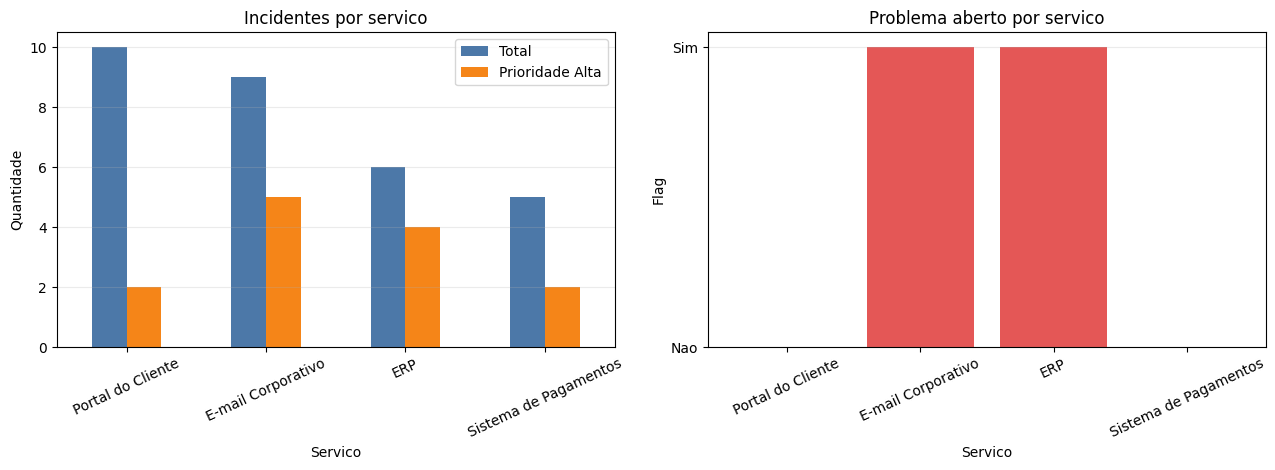

Grafico salvo em: saidas/painel_governanca_lab13.png


In [5]:
painel_plot = painel.sort_values("total_incidentes", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

painel_plot[["total_incidentes", "incidentes_prioridade_alta"]].plot(
    kind="bar",
    ax=axes[0],
    color=["#4c78a8", "#f58518"],
)
axes[0].set_title("Incidentes por servico")
axes[0].set_xlabel("Servico")
axes[0].set_ylabel("Quantidade")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(["Total", "Prioridade Alta"])
axes[0].grid(axis="y", alpha=0.25)

cores_problema = ["#e45756" if valor == 1 else "#72b7b2" for valor in painel_plot["problema_aberto"]]
axes[1].bar(painel_plot.index, painel_plot["problema_aberto"], color=cores_problema)
axes[1].set_title("Problema aberto por servico")
axes[1].set_xlabel("Servico")
axes[1].set_ylabel("Flag")
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["Nao", "Sim"])
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
arquivo_grafico = SAIDAS_DIR / "painel_governanca_lab13.png"
fig.savefig(arquivo_grafico, dpi=140, bbox_inches="tight")
plt.show()

print(f"Grafico salvo em: {arquivo_grafico}")


## 8. Analise dos resultados

A celula abaixo interpreta automaticamente o painel gerado. Isso evita escrever uma conclusao
fixa que poderia ficar incorreta se a base ou a semente de geracao fossem alteradas.


In [6]:
servicos_com_problema = painel[painel["problema_aberto"] == 1].index.tolist()
servico_maior_volume = painel["total_incidentes"].idxmax()
servico_maior_alta = painel["incidentes_prioridade_alta"].idxmax()
taxa_problemas = resumo_governanca.loc[
    resumo_governanca["indicador"] == "Taxa de servicos com Problema aberto", "valor"
].iloc[0]

print("Analise executiva:")
print(f"- Servico com maior volume total de incidentes: {servico_maior_volume}.")
print(f"- Servico com maior quantidade de incidentes Alta: {servico_maior_alta}.")

if servicos_com_problema:
    print("- Servicos com Problema aberto: " + ", ".join(servicos_com_problema) + ".")
else:
    print("- Nenhum servico teve Problema aberto.")

print(f"- Taxa de servicos com Problema aberto: {taxa_problemas}.")
print("- Acao recomendada: priorizar investigacao de causa raiz nos servicos marcados com Problema aberto.")


Analise executiva:
- Servico com maior volume total de incidentes: Portal do Cliente.
- Servico com maior quantidade de incidentes Alta: E-mail Corporativo.
- Servicos com Problema aberto: E-mail Corporativo, ERP.
- Taxa de servicos com Problema aberto: 50.0%.
- Acao recomendada: priorizar investigacao de causa raiz nos servicos marcados com Problema aberto.


## 9. Conclusao

A Atividade 3 foi implementada com um painel consolidado que une incidentes, recorrencia de
Prioridade Alta e abertura de Problemas. A entrega tambem registra a taxa de servicos com
Problema aberto, que funciona como indicador de risco operacional para a governanca de TI.

Com a base gerada neste laboratorio, o painel permite diferenciar servicos apenas monitorados
daqueles que exigem investigacao de causa raiz, seguindo a logica do Gerenciamento de Problemas
do ITIL.
